# Fase de Modelagem: Baseline (Regressão Linear)

O objetivo deste notebook é estabelecer nosso modelo "linha de base" (Baseline). 
Antes de tentarmos algoritmos complexos (como Random Forest ), precisamos saber qual é o erro padrão de um modelo simples. Se um modelo complexo não conseguir bater a Regressão Linear, ele não vale o custo computacional.

**Passos:**
1. Filtrar os dados apenas para o período diurno (evitar que o modelo decore que "de noite não tem sol").
2. Aplicar Validação Cruzada (K-Fold) para garantir robustez.
3. Treinar o modelo e visualizar os acertos e os erros (resíduos).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# ==========================================
# PREPARAÇÃO DOS DADOS 
# ==========================================
df = pd.read_csv('../data/INMET_Pampulha_Limpo.csv')

# Convertendo a data de volta e recriando colunas de tempo
df['data_hora_local'] = pd.to_datetime(df['data_hora_local'])
df['hora'] = df['data_hora_local'].dt.hour
df['mes'] = df['data_hora_local'].dt.month

# CRUCIAL: Filtrar apenas os dados diurnos para o modelo não "roubar" com a noite
df_day = df[(df['hora'] >= 6) & (df['hora'] <= 18)].copy()

In [6]:
# Definindo as Features (X) e a Variável Alvo (y)
features = ['hora', 'temp_ar', 'umidade_relativa', 'pressao_atm', 'vento_rajada', 'mes']
X = df_day[features]
y = df_day['radiacao_global']

## 1. Validação Cruzada (K-Fold) vs Holdout (80/20)
Para garantir que nosso modelo não está sendo testado em um "pedaço fácil" ou "difícil" dos dados, vamos usar o K-Fold com 5 dobras. O modelo será treinado 5 vezes, rodando por todos os períodos do dataset.

Logo após, faremos a divisão 80/20 (Holdout) para podermos extrair os dados previstos e gerar os gráficos de visualização.

In [11]:
# Inicializando o modelo
lr_model = LinearRegression()

# 1. VALIDAÇÃO CRUZADA (K-Fold = 5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()

print(f"Resultado do K-Fold (5 folds):")
print(f"MAE Médio Consolidado: {cv_mae:.2f} Kj/m²\n")

# 2. DIVISÃO HOLDOUT (Para os gráficos e métricas finais)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Métricas Tradicionais
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("--- Métricas do Teste (80/20) ---")
print(f"MAE: {mae:.2f} Kj/m²")
print(f"RMSE: {rmse:.2f} Kj/m²")
print(f"R²: {r2:.4f} (O modelo explica {r2*100:.1f}% da variação da radiação)")

Resultado do K-Fold (5 folds):
MAE Médio Consolidado: 512.48 Kj/m²

--- Métricas do Teste (80/20) ---
MAE: 529.33 Kj/m²
RMSE: 648.42 Kj/m²
R²: 0.6543 (O modelo explica 65.4% da variação da radiação)


## 2. Visualização de Desempenho e Erros
Apenas olhar para os números (MAE, RMSE) não nos diz *onde* o modelo está errando. 
Vamos gerar dois gráficos fundamentais:
1. **Real vs. Previsto:** Se o modelo for perfeito, todos os pontos formarão uma linha reta diagonal.
2. **Distribuição de Resíduos (Erros):** Mostra se o modelo está subestimando ou superestimando a radiação. O ideal é que os erros estejam concentrados no centro (zero).

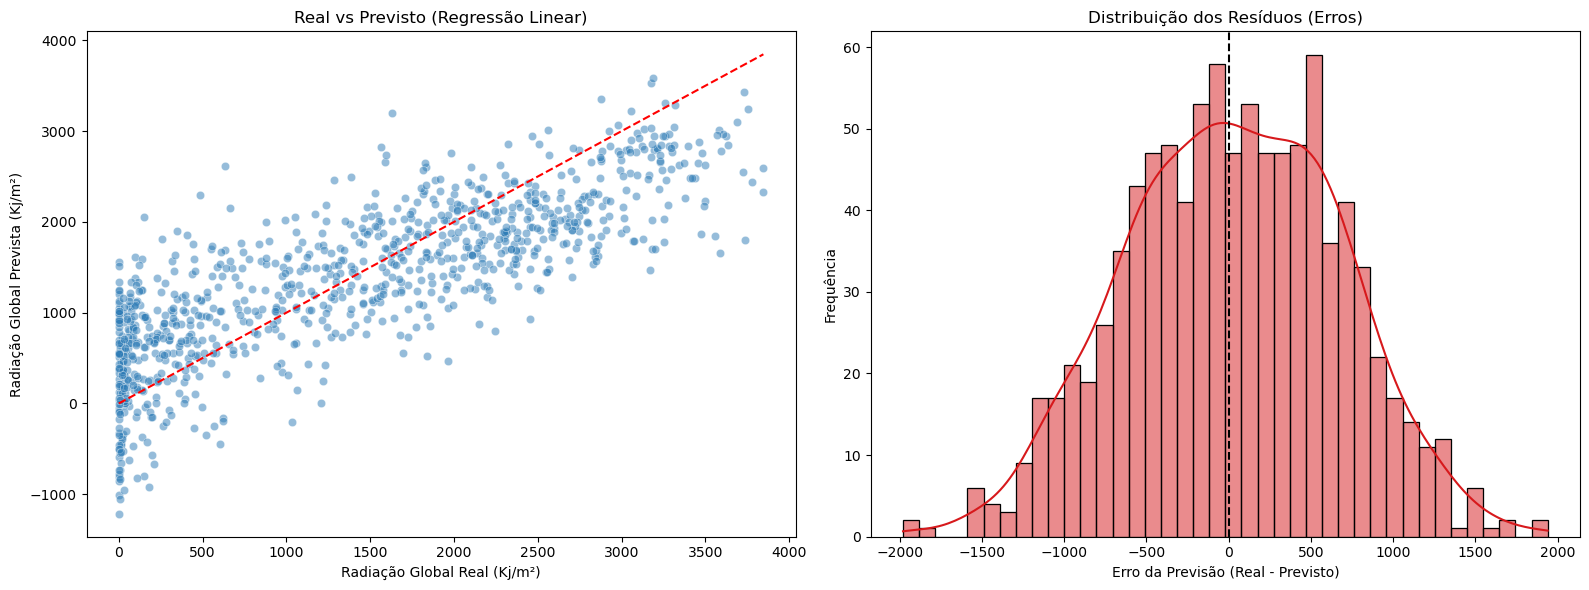

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Valores Reais vs Previstos
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5, ax=axes[0], color='#2c7bb6')
# Linha de perfeição (onde Real = Previsto)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
axes[0].set_title('Real vs Previsto (Regressão Linear)')
axes[0].set_xlabel('Radiação Global Real (Kj/m²)')
axes[0].set_ylabel('Radiação Global Prevista (Kj/m²)')

# Gráfico 2: Distribuição dos Resíduos (Erros)
residuos = y_test - y_pred_lr
sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color='#d7191c')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribuição dos Resíduos (Erros)')
axes[1].set_xlabel('Erro da Previsão (Real - Previsto)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Conclusões do Modelo Baseline

A Regressão Linear nos forneceu uma excelente base de comparação e revelou comportamentos importantes sobre a natureza dos nossos dados climáticos:

1. **Robustez e Generalização:** O MAE do K-Fold (512.48) ficou muito próximo do MAE do teste Holdout (529.33). Isso é um ótimo sinal! Significa que o modelo aprendeu um padrão real e não sofreu *overfitting* (sobreajuste). Ele generaliza bem para dados que nunca viu.
2. **Capacidade Explicativa (R²):** Um R² de 65.4% para um fenômeno meteorológico complexo usando apenas uma equação linear é um resultado bastante respeitável. Ele confirma que as features escolhidas (especialmente Temperatura e Hora) têm forte poder preditivo.
3. **O Limite da Linearidade (Análise Visual):** Observando os gráficos, fica claro por que precisamos de um modelo mais avançado:
    * **Valores Impossíveis:** No gráfico "Real vs Previsto", a Regressão Linear previu valores negativos de radiação, pois ela é apenas uma reta matemática sem limites físicos.
    * **O "Problema das Nuvens":** Note a densa coluna de pontos onde a *Radiação Real* é 0, mas o modelo previu valores entre 0 e 2000. Isso acontece porque a Regressão Linear tenta fazer uma "média". Em um dia nublado ao meio-dia, ela olha para a hora e chuta a radiação lá em cima, ignorando que o sistema sofreu uma interrupção bruta.
4. **Distribuição dos Erros:** O histograma de resíduos é razoavelmente normalizado e centrado em zero, mostrando que o modelo não é enviesado, mas a "cauda" larga demonstra que há margem para melhorar a precisão.

**Próximo Passo:**
Para bater essa *baseline*, o próximo modelo precisa lidar com a **não-linearidade** (entender que a radiação não pode ser menor que zero) e capturar regras lógicas mais complexas (ex: "se for meio-dia E a umidade estiver muito alta, a radiação despenca"). O **Random Forest** é o candidato ideal para resolver essas falhas do modelo linear.